# Redshift-Space Multipoles

Monopole `xi_0(s)` and quadrupole `xi_2(s)` from galaxy velocities. Supports a standard Landy-Szalay estimator and a subvolume-weighted estimator that corrects for sub-sampling bias.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

import galform_analysis
from galform_analysis import set_base_dir, get_base_dir, SimulationConfig, load_redshift_mapping

mpl.setconfig()

# Configure the path to your GALFORM output directory once per session:
# set_base_dir('/cosma5/data/durham/<user>/Galform_Out/L800/model')
BASE_DIR = str(get_base_dir())
SIM = 'L800'

## Load positions in redshift space

In [2]:
from galform_analysis.analysis.correlation import (
    compute_weighted_rsd_multipoles,
    compute_standard_rsd_multipoles,
)
from galform_analysis.utils.read_galaxies import read_galaxy_arrays
from galform_analysis.config import SimulationConfig, get_snapshot_redshift
import os

IZ_NUM = 155
IVOLS  = [0, 1]
iz_path = os.path.join(BASE_DIR, f'iz{IZ_NUM}')

sim    = SimulationConfig(SIM)
z_snap = get_snapshot_redshift(f'iz{IZ_NUM}', SIM) or 0.0
# Hubble parameter at z: H(z) = 100 h E(z)  [km/s/(Mpc/h)]
Ez  = np.sqrt(sim.omega_m * (1 + z_snap)**3 + sim.omega_l)
H_z = 100.0 * sim.h * Ez

S_BINS    = np.logspace(-1, 1.5, 12)
N_RANDOM  = 50_000
BOXSIZE   = sim.box_size

rng = np.random.default_rng(42)

pos_chunks, label_chunks = [], []
for label, iv in enumerate(IVOLS):
    arrays, _ = read_galaxy_arrays(
        iz_path, ivol=iv,
        fields=['vzgal'], include_positions=True, include_derived=True, centrals_only=False
    )
    x   = np.asarray(arrays['x'],   dtype=np.float64)
    y   = np.asarray(arrays['y'],   dtype=np.float64)
    z   = np.asarray(arrays['z'],   dtype=np.float64)
    vz  = np.asarray(arrays.get('vzgal', np.zeros_like(z)), dtype=np.float64)
    z_rsd = np.mod(z + (vz / H_z) * sim.h, BOXSIZE)
    pos_chunks.append(np.column_stack([x, y, z_rsd]))
    label_chunks.append(np.full(len(x), label, dtype=np.int64))

galaxy_pos    = np.ascontiguousarray(np.vstack(pos_chunks), dtype=np.float64)
galaxy_labels = np.ascontiguousarray(np.concatenate(label_chunks), dtype=np.int64)
random_pos    = np.ascontiguousarray(rng.uniform(0, BOXSIZE, (N_RANDOM, 3)), dtype=np.float64)
print(f"Galaxies: {len(galaxy_pos):,},  randoms: {N_RANDOM:,}")

Galaxies: 569,253,  randoms: 50,000


## Standard Landy-Szalay monopole and quadrupole

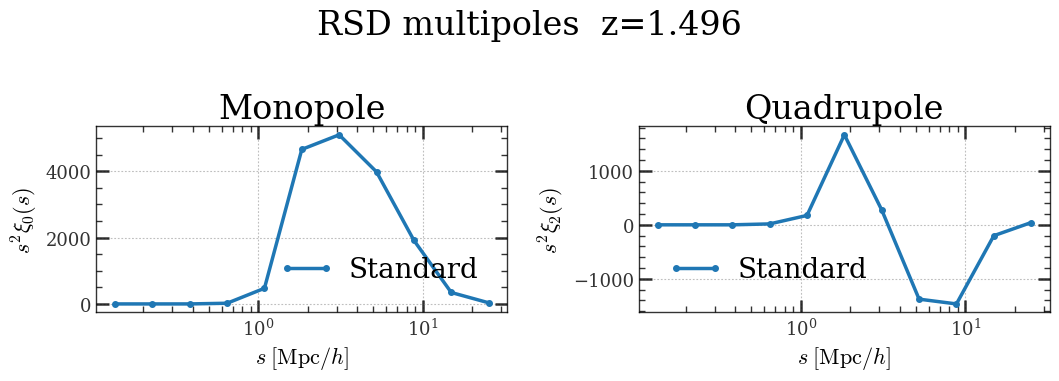

In [3]:
std = compute_standard_rsd_multipoles(
    galaxy_pos=galaxy_pos,
    random_pos=random_pos,
    s_bins=S_BINS,
    boxsize=BOXSIZE,
    nthreads=4,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(std['s'], std['s']**2 * std['xi0'], 'o-', ms=4, label='Standard')
ax.set_xscale('log')
ax.set_xlabel(r'$s\;[\mathrm{Mpc}/h]$'); ax.set_ylabel(r'$s^2\xi_0(s)$')
ax.set_title('Monopole'); ax.legend()

ax = axes[1]
ax.plot(std['s'], std['s']**2 * std['xi2'], 'o-', ms=4, label='Standard')
ax.set_xscale('log')
ax.set_xlabel(r'$s\;[\mathrm{Mpc}/h]$'); ax.set_ylabel(r'$s^2\xi_2(s)$')
ax.set_title('Quadrupole'); ax.legend()

fig.suptitle(f'RSD multipoles  z={z_snap:.3f}')
fig.tight_layout()
plt.show()

## Subvolume-weighted estimator (corrects sub-sampling bias)

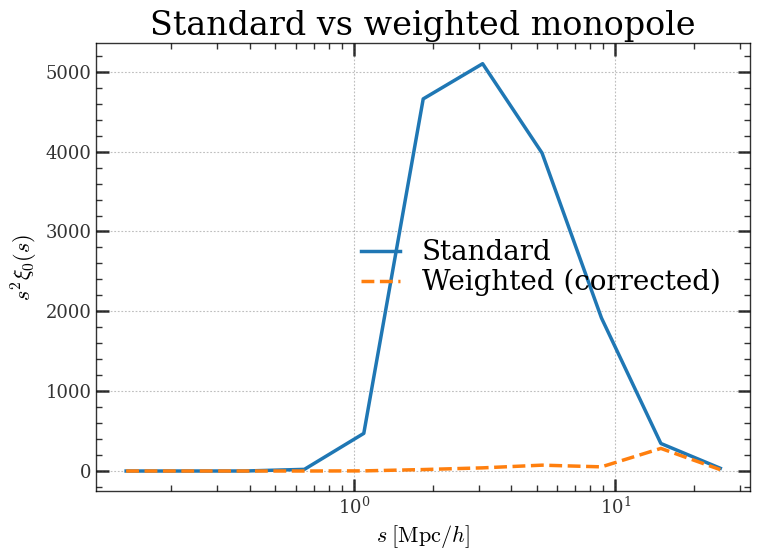

In [4]:
weighted = compute_weighted_rsd_multipoles(
    galaxy_pos=galaxy_pos,
    galaxy_labels=galaxy_labels,
    random_pos=random_pos,
    s_bins=S_BINS,
    boxsize=BOXSIZE,
    nthreads=4,
)

fig, ax = plt.subplots()
ax.plot(std['s'],      std['s']**2      * std['xi0'],              label='Standard')
ax.plot(weighted['s'], weighted['s']**2 * weighted['xi0_corrected'], ls='--', label='Weighted (corrected)')
ax.set_xscale('log')
ax.set_xlabel(r'$s\;[\mathrm{Mpc}/h]$'); ax.set_ylabel(r'$s^2\xi_0(s)$')
ax.set_title('Standard vs weighted monopole')
ax.legend(); fig.tight_layout(); plt.show()